# Characters and $A_4$ orbits in three dimensions

Edit the **settings cell immediately below**, then run all cells. The main controls
are `xi_0`, `COLOR_MODE`, and `SHOW_SHELL`.

- `"cycles"`: four colors for the four $P$ cycles of a 12-point orbit, with charcoal
  $D$ connections. The frequency plot, schematic $A_4$ graph, and generator legend
  use the same assignments.
- `"generators"`: red $P$ arrows and blue $D$ connections throughout.
- `SHOW_SHELL`: show or hide the small wireframe around each character cube,
  colored by its $P$ cycle. The outer box, wall grids, and axis labels
  $\xi_1,\xi_2,\xi_3$ are always visible. Shell colors identify cycles even
  when the arrows use the red/blue generator scheme.

Each panel has its own export cell. Outputs are `a4_orbit_graph.svg`,
`a4_generator_legend.svg`, `character_bank.svg`, `orbit_sum.svg`, and
`unique_orbit_sums.svg` (a **5-column × 4-row grid**). Individual superposition
exports are retained behind `SAVE_INDIVIDUAL_ORBIT_SUMS`; individual character
cubes are never exported. SVGs contain vector edges and embedded raster face
textures; optional PNGs use the same transparent-background setting.

The schematic graph arranges vertices for readability; the character bank places
them at their actual frequency coordinates. Translation characters are complex
exponentials; the cubes display their real parts (cosines). Opposite frequencies
have identical real parts, so the superposition collection pairs each orbit with
its negative. An orbit plus an irrep of its stabilizer labels an induced irrep;
an orbit alone suffices when the stabilizer is trivial.

In [45]:
from pathlib import Path
from itertools import product
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, Polygon

# ======================== MAIN SETTINGS ========================
xi_0 = np.array([1, 2, 3])       # e.g. [1, 1, 1], [1, 0, 0], [3, 1, 1]
COLOR_MODE = "cycles"           # "cycles" or "generators" (red / blue)
SHOW_SHELL = True               # small colored wireframe around each character cube

n = 60
sheet_frequencies = np.arange(-3, 4)
CAMERA_AZIMUTH = 44             # degrees; keep in the (+,+,+) octant
CAMERA_ELEVATION = 30           # degrees; keep between 0 and 90

# Superpositions: same frequency block and radius convention as before.
INCLUDE_ORIGIN = True
SUPERPOSITION_MAX_NORM2 = None  # None -> ||centered(xi_0)||^2
SAVE_INDIVIDUAL_ORBIT_SUMS = True

# Display / export options.
LABEL_VERTICES = False          # labels on the schematic graph only
SAVE_PNG = False
TRANSPARENT = True
SHOW = True
CYCLE_COLORS = ("#00A6FF", "#FF5A36", "#00C853", "#B040FF")
P_COLOR = "#ed2424"
D_COLOR = "#2455ed"
NEUTRAL_COLOR = "#3b3b3b"

# Reuse `figures` if this notebook is run in an existing project session.
figures = Path(globals().get("figures", Path.cwd() / "figures"))
output_dir = figures / "figure_8_panel_c"
output_dir.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({"svg.fonttype": "none", "font.family": "DejaVu Sans"})

if COLOR_MODE not in {"cycles", "generators"}:
    raise ValueError('COLOR_MODE must be "cycles" or "generators".')
if not isinstance(n, (int, np.integer)) or n < 2:
    raise ValueError("n must be an integer >= 2.")
xi_0 = np.asarray(xi_0)
if xi_0.shape != (3,) or not np.all(np.isfinite(xi_0)) or not np.all(xi_0 == np.round(xi_0)):
    raise ValueError("xi_0 must contain three integer frequencies.")
xi_0 = xi_0.astype(int)
if not (0 < CAMERA_AZIMUTH < 90 and 0 < CAMERA_ELEVATION < 90):
    raise ValueError("The three-face renderer requires camera angles between 0 and 90 degrees.")

## Group, modular orbit, and consistent cycle colors
The generators are $P:(a,b,c)\mapsto(b,c,a)$ and
$D:(a,b,c)\mapsto(a,-b,-c)$. Colors are assigned once, beginning with the
$P$ cycle containing $\xi_0$. Smaller orbits can contain fewer cycles and fixed
points; fixed-point loops are omitted from the drawings.

In [46]:
D = np.diag([1, -1, -1])
P = np.array([[0, 1, 0], [0, 0, 1], [1, 0, 0]])
group, frontier = [np.eye(3, dtype=int)], [np.eye(3, dtype=int)]
while frontier:                          # closure of {D, P}: the twelve rotations of the tetrahedron
    new = []
    for g in frontier:
        for h in (D, P):
            candidate = h @ g
            if not any(np.array_equal(candidate, k) for k in group):
                group.append(candidate)
                new.append(candidate)
    frontier = new
assert len(group) == 12

def as_tuple(v):
    return tuple(int(x) for x in v)


def centered(v):
    return tuple((int(x) + n // 2) % n - n // 2 for x in v)


def orbit_of(q):
    return sorted({centered(g @ np.asarray(q)) for g in group})


def negated(frequencies):
    return sorted({centered(-np.asarray(q)) for q in frequencies})

orbit = orbit_of(xi_0)
assert n >= 2
assert all(np.array_equal(g.T @ g, np.eye(3)) and round(np.linalg.det(g)) == 1 for g in group)
assert all(centered(h @ np.array(q)) in orbit for h in (P, D) for q in orbit)


# Partition the orbit into P cycles (length 3, or length 1 at a fixed point).
p_cycles, seen_cycle = [], set()
for q in [centered(xi_0), *orbit]:
    if q in seen_cycle:
        continue
    cycle, point = [], q
    while point not in cycle:
        cycle.append(point)
        point = centered(P @ np.asarray(point))
    p_cycles.append(tuple(cycle))
    seen_cycle.update(cycle)
cycle_index = {q: i for i, cycle in enumerate(p_cycles) for q in cycle}
cycle_color = {q: CYCLE_COLORS[i] for q, i in cycle_index.items()}
assert seen_cycle == set(orbit)
assert all(len(cycle) in (1, 3) for cycle in p_cycles)


def p_edge_color(q):
    return cycle_color[q] if COLOR_MODE == "cycles" else P_COLOR


def d_edge_color():
    return NEUTRAL_COLOR if COLOR_MODE == "cycles" else D_COLOR


print(f"Orbit of {centered(xi_0)}: {len(orbit)} points; stabilizer size {12 // len(orbit)}")
print(f"P-cycle lengths: {[len(cycle) for cycle in p_cycles]}")

Orbit of (1, 2, 3): 12 points; stabilizer size 1
P-cycle lengths: [3, 3, 3, 3]


## Shared rendering and export helpers
The three faces show coordinate-zero slices. Characters map $[-1,1]$ to $[0,1]$
for coloring; superpositions are normalized jointly across their three faces.

In [47]:
def save_svg(figure, filename, show=None):
    path = output_dir / filename
    figure.savefig(path, bbox_inches="tight", pad_inches=0.08, transparent=TRANSPARENT)
    if SAVE_PNG:
        figure.savefig(path.with_suffix(".png"), dpi=250, bbox_inches="tight",
                       pad_inches=0.08, transparent=TRANSPARENT)
    if (SHOW if show is None else show):
        plt.show()
    plt.close(figure)
    print(f"Saved SVG: {path}")


def blank_axes(size=(5, 5)):
    figure, axis = plt.subplots(figsize=size)
    axis.set_aspect("equal")
    axis.axis("off")
    return figure, axis


row, col = np.meshgrid(np.arange(n), np.arange(n), indexing="ij")
# Top face a3=0 shows (a1, a2), right face a1=0 shows (a2, a3), left face a2=0 shows (a1, a3); rows are the second coordinate.
face_axes = {"+z": (0, 1), "+x": (1, 2), "+y": (0, 2)}
character_faces = lambda q: {face: np.cos(2 * np.pi * (q[u] * col + q[v] * row) / n) for face, (u, v) in face_axes.items()}


def orbit_sum_faces(frequencies):
    # Real part of the orbit sum on the three faces, mapped jointly to [0, 1] for display.
    faces = {face: sum(character_faces(q)[face] for q in frequencies) for face in face_axes}
    low, high = min(f.min() for f in faces.values()), max(f.max() for f in faces.values())
    if high - low < 1e-9:                                           # the trivial orbit {0}: a constant at its maximum
        return {face: np.ones_like(f) for face, f in faces.items()}
    return {face: (f - low) / (high - low) for face, f in faces.items()}


# --- an orthographic camera in the (+,+,+) octant, and cube glyphs ---------------------------------------------------------
azimuth, elevation = np.deg2rad(CAMERA_AZIMUTH), np.deg2rad(CAMERA_ELEVATION)       # chosen so the twelve orbit points stay apart on screen
view = np.array([np.cos(elevation) * np.cos(azimuth), np.cos(elevation) * np.sin(azimuth), np.sin(elevation)])
right = np.array([-np.sin(azimuth), np.cos(azimuth), 0.0])
up = np.array([-np.sin(elevation) * np.cos(azimuth), -np.sin(elevation) * np.sin(azimuth), np.cos(elevation)])
project = lambda v: np.array([np.dot(v, right), np.dot(v, up)])
depth = lambda v: float(np.dot(v, view))
unit = np.eye(3)
colormap = plt.get_cmap("coolwarm")
face_shading = {"+z": 1.0, "+x": 0.86, "+y": 0.74}
face_frame = {"+z": ((-1, -1, 1), 0, 1), "+x": ((1, -1, -1), 1, 2), "+y": ((-1, 1, -1), 0, 2)}   # corner, column axis, row axis


def rasterize_face(image_rgb, origin, col_vector, row_vector, pixels_per_unit):
    # Warp a face image onto its projected parallelogram; outside the parallelogram the raster is transparent.
    corners = np.array([origin, origin + col_vector, origin + col_vector + row_vector, origin + row_vector])
    (x0, y0), (x1, y1) = corners.min(axis=0), corners.max(axis=0)
    width, height = max(int(np.ceil((x1 - x0) * pixels_per_unit)), 2), max(int(np.ceil((y1 - y0) * pixels_per_unit)), 2)
    xs = x0 + (np.arange(width) + 0.5) * (x1 - x0) / width
    ys = y0 + (np.arange(height) + 0.5) * (y1 - y0) / height
    uv = (np.stack(np.meshgrid(xs, ys), axis=-1) - origin) @ np.linalg.inv(np.column_stack([col_vector, row_vector])).T
    inside = np.all((uv >= 0) & (uv < 1), axis=-1)
    rows, cols = image_rgb.shape[:2]
    j = np.clip((uv[..., 1] * rows).astype(int), 0, rows - 1)
    i = np.clip((uv[..., 0] * cols).astype(int), 0, cols - 1)
    rgba = np.zeros((height, width, 4))
    rgba[..., :3], rgba[..., 3] = image_rgb[j, i], inside
    return rgba, (x0, x1, y0, y1), corners


def draw_cube(ax, centre, half, faces, edgecolor="black", linewidth=1.2, zorder=1, pixels_per_unit=200, shift=(0.0, 0.0)):
    # faces: {"+z", "+x", "+y"} -> image in [0, 1], drawn with coolwarm on the three visible faces of the cube.
    # shift moves the projected glyph on screen, for laying out glyphs on a 2D grid.
    centre = np.asarray(centre, dtype=float)
    for face, (corner, col_axis, row_axis) in face_frame.items():
        origin = project(centre + half * np.array(corner)) + np.asarray(shift, float)
        col_vector, row_vector = project(2 * half * unit[col_axis]), project(2 * half * unit[row_axis])
        rgb = colormap(np.clip(faces[face], 0, 1))[..., :3] * face_shading[face]
        rgba, extent, corners = rasterize_face(rgb, origin, col_vector, row_vector, pixels_per_unit)
        ax.imshow(rgba, origin="lower", extent=extent, interpolation="antialiased", zorder=zorder)
        ax.add_patch(Polygon(corners, closed=True, fill=False, edgecolor=edgecolor, linewidth=linewidth, joinstyle="round",
                             zorder=zorder + 0.5))


def segment(ax, start, end, zorder=0, **style):
    ax.plot(*zip(project(np.asarray(start, float)), project(np.asarray(end, float))), zorder=zorder, **style)


def draw_cell_wireframe(ax, centre, half, zorder, split_depth, **style):
    # The twelve edges of a cube; edges nearer the camera than split_depth go just above zorder, the others just below.
    centre = np.asarray(centre, float)
    for axis in range(3):
        for other in np.ndindex(2, 2):
            start = centre.copy()
            start[[(axis + 1) % 3, (axis + 2) % 3]] += half * (2 * np.array(other) - 1)
            start[axis] -= half
            end = start.copy()
            end[axis] += 2 * half
            segment(ax, start, end, zorder=zorder + (0.7 if depth((start + end) / 2) > split_depth else -0.7), **style)


def frame_cube(axis):
    # Fit all eight projected corners, including after a camera-angle change.
    radius = max(np.abs(right).sum(), np.abs(up).sum()) + 0.12
    axis.set(xlim=(-radius, radius), ylim=(-radius, radius))


def draw_generator_edges(axis, positions, linewidth=2.2, shrink=13, zorder=1):
    # Each undirected D edge once. P arrows follow the cyclic orientation.
    for q in orbit:
        target = centered(D @ np.asarray(q))
        if q < target:
            axis.add_patch(FancyArrowPatch(
                positions[q], positions[target], arrowstyle="-",
                shrinkA=shrink, shrinkB=shrink, color=d_edge_color(),
                linewidth=linewidth, zorder=zorder,
            ))
    for q in orbit:
        target = centered(P @ np.asarray(q))
        if target != q:
            axis.add_patch(FancyArrowPatch(
                positions[q], positions[target], arrowstyle="-|>",
                mutation_scale=18 if linewidth >= 2 else 12,
                shrinkA=shrink, shrinkB=shrink, color=p_edge_color(q),
                linewidth=linewidth, zorder=zorder + 0.1,
            ))

## 1. Schematic $A_4$ orbit graph
For a 12-point orbit, the inverse group labels give the truncated-tetrahedron
layout. This is the Cayley graph for the chosen generators when the stabilizer
is trivial; smaller orbits give a Schreier graph and use a circular layout.
The cycle colors agree with the actual-frequency plot below.

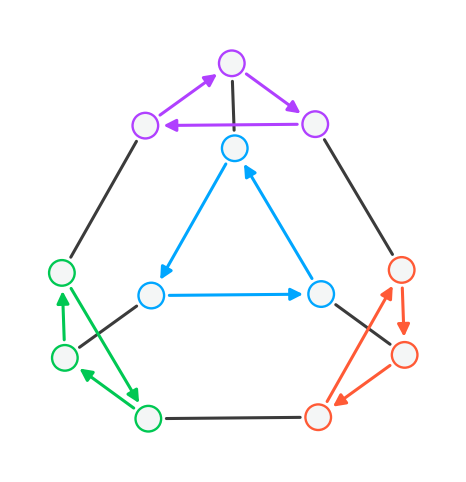

Saved SVG: /Users/danielkunin/Desktop/Grid Cells and Group Composition/code/neural-data/Ginosar/figures/figure_8_panel_c/a4_orbit_graph.svg


In [48]:
figure, axis = blank_axes((6, 6))
if len(orbit) == 12:
    seed = np.array([3., 1., 1.])
    positions = {centered(g @ xi_0): project(g.T @ seed) for g in group}
else:
    positions = {q: np.array([np.cos(t), np.sin(t)]) for q, t in
                 zip(orbit, np.linspace(0, 2*np.pi, len(orbit), endpoint=False))}

draw_generator_edges(axis, positions)
xy = np.array([positions[q] for q in orbit])
vertex_colors = [cycle_color[q] if COLOR_MODE == "cycles" else NEUTRAL_COLOR for q in orbit]
axis.scatter(xy[:, 0], xy[:, 1], s=340, facecolor="#f4f6f6",
             edgecolors=vertex_colors, linewidth=1.7, zorder=3)
if LABEL_VERTICES:
    for q, p in positions.items():
        axis.annotate(str(q), p, xytext=(0, 15), textcoords="offset points",
                      ha="center", fontsize=9)
axis.update_datalim(xy)
axis.autoscale_view()
axis.margins(0.15)
save_svg(figure, "a4_orbit_graph.svg")

## 2. Matching generator legend

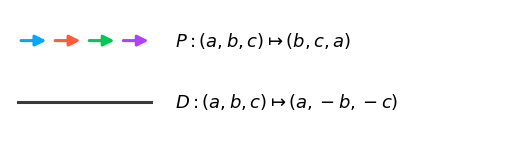

Saved SVG: /Users/danielkunin/Desktop/Grid Cells and Group Composition/code/neural-data/Ginosar/figures/figure_8_panel_c/a4_generator_legend.svg


In [49]:
figure, axis = plt.subplots(figsize=(6.4, 1.6))
axis.axis("off")
legend_colors = [CYCLE_COLORS[i] for i in range(len(p_cycles))] if COLOR_MODE == "cycles" else [P_COLOR]
width = 1.65 / len(legend_colors)
for i, color in enumerate(legend_colors):
    axis.add_patch(FancyArrowPatch(
        (i * width, 1), ((i + 1) * width - 0.04, 1),
        arrowstyle="-|>", mutation_scale=16, color=color, linewidth=2.2,
    ))
axis.plot([0, 1.61], [0, 0], color=d_edge_color(), linewidth=2.2)
axis.text(1.9, 1, r"$P: (a,b,c) \mapsto (b,c,a)$", va="center", fontsize=13)
axis.text(1.9, 0, r"$D: (a,b,c) \mapsto (a,-b,-c)$", va="center", fontsize=13)
axis.set(xlim=(-0.1, 5.9), ylim=(-0.5, 1.5))
save_svg(figure, "a4_generator_legend.svg")

## 3. $C_n^3$ characters at actual frequency coordinates
Arrow colors distinguish the same $P$ cycles as in the schematic graph, or
the two generators when `COLOR_MODE = "generators"`. `SHOW_SHELL` controls
the small wireframe around each character cube, colored by its $P$ cycle
in either arrow-color mode. The outer box and wall grids are always drawn,
with $\xi_1,\xi_2,\xi_3$ as axis labels. There are no per-cube coordinate
labels, dotted drop lines, or floor markers.

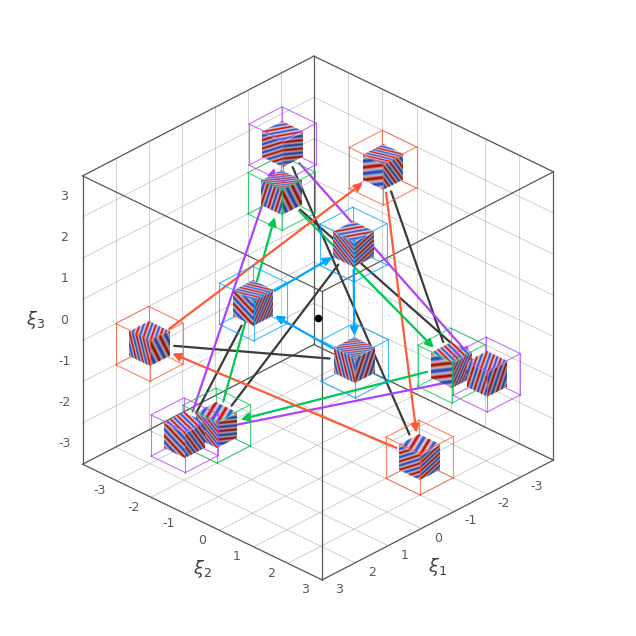

Saved SVG: /Users/danielkunin/Desktop/Grid Cells and Group Composition/code/neural-data/Ginosar/figures/figure_8_panel_c/character_bank.svg


In [50]:
figure, bank = blank_axes((8, 8))
block = max(np.max(np.abs(sheet_frequencies)), np.max(np.abs(orbit))) + 0.5

# The outer frequency box and wall grids are always shown.
cell_edges = np.arange(-block, block + 1)
for wall_axis in range(3):
    u_axis, v_axis = (wall_axis + 1) % 3, (wall_axis + 2) % 3
    for value in cell_edges:
        for line_axis, other_axis in ((u_axis, v_axis), (v_axis, u_axis)):
            start, end = np.zeros(3), np.zeros(3)
            start[wall_axis] = end[wall_axis] = -block
            start[other_axis] = end[other_axis] = value
            start[line_axis], end[line_axis] = -block, block
            segment(bank, start, end, zorder=-5, color="0.72", linewidth=0.45)
draw_cell_wireframe(bank, (0, 0, 0), block, zorder=-4,
                    split_depth=depth(np.zeros(3)), color="0.35", linewidth=0.9)

# Keep the coordinate labels on the outer frequency box.
for dimension, anchor, offset in (
    (0, np.array([0, block, -block]), np.array([0.0, -0.38])),
    (1, np.array([block, 0, -block]), np.array([0.0, -0.38])),
    (2, np.array([block, -block, 0]), np.array([-0.38, 0.0])),
):
    for tick in sheet_frequencies:
        position = anchor.astype(float)
        position[dimension] = tick
        bank.text(*(project(position) + offset), str(tick), ha="center",
                  va="center", fontsize=9, color="0.35", zorder=300)
    label_position = anchor.astype(float)
    label_position[dimension] = 0
    bank.text(*(project(label_position) + 2.6 * offset),
              (r"$\xi_1$", r"$\xi_2$", r"$\xi_3$")[dimension],
              ha="center", va="center", fontsize=13, color="0.25", zorder=300)
bank.plot(*project(np.zeros(3)), marker="o", markersize=4.5, color="black", zorder=-1)

positions = {q: project(q) for q in orbit}
draw_generator_edges(bank, positions, linewidth=1.6, shrink=18, zorder=5)
half = 0.30
order = sorted(orbit, key=lambda q: depth(np.asarray(q, dtype=float)))
for rank, q in enumerate(order):
    faces = {face: (value + 1) / 2 for face, value in character_faces(q).items()}
    z = 10 + 2 * rank
    draw_cube(bank, q, half, faces, edgecolor="none", linewidth=0, zorder=z)
    if SHOW_SHELL:
        # Match the original unit-cell shell; its color identifies the P cycle.
        draw_cell_wireframe(
            bank, q, 0.5, zorder=z, split_depth=depth(np.asarray(q, dtype=float)),
            color=cycle_color[q], linewidth=0.8, alpha=0.75,
        )

span = 1.85 * block
bank.set(xlim=(-span, span), ylim=(-span, span))
save_svg(figure, "character_bank.svg")

## 4. Selected orbit superposition

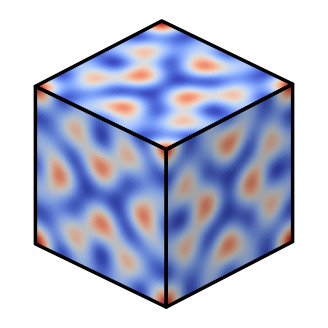

Saved SVG: /Users/danielkunin/Desktop/Grid Cells and Group Composition/code/neural-data/Ginosar/figures/figure_8_panel_c/orbit_sum.svg


In [51]:
figure, axis = blank_axes((4, 4))
draw_cube(axis, (0, 0, 0), 1.0, orbit_sum_faces(orbit), linewidth=2.5, pixels_per_unit=380)
frame_cube(axis)
save_svg(figure, "orbit_sum.svg")

## 5. Distinct real superpositions — 5 columns × 4 rows
Use the same selection as the previous notebook: representatives in
`sheet_frequencies` with squared norm at most $\|\xi_0\|^2$ (or the explicit
`SUPERPOSITION_MAX_NORM2` setting), ordered by squared norm. Pair each orbit with
its negative to avoid conjugate duplicates. With the default settings this gives
19 superpositions and one empty slot. The selected orbit has a heavier outline.

This is the selected low-frequency collection, not every orbit in $C_n^3$.
If a changed selection exceeds 20 superpositions, reduce
`SUPERPOSITION_MAX_NORM2` to fit the fixed grid; the code reports the count
rather than silently dropping entries.

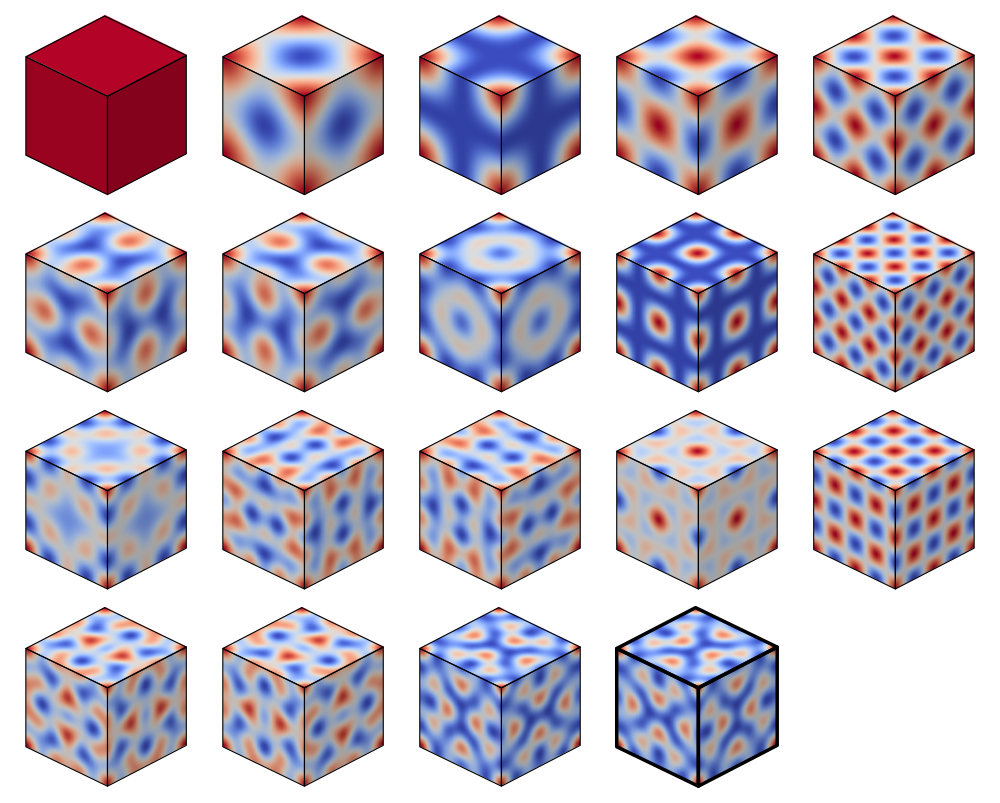

Saved SVG: /Users/danielkunin/Desktop/Grid Cells and Group Composition/code/neural-data/Ginosar/figures/figure_8_panel_c/unique_orbit_sums.svg
Displayed all 19 selected superpositions in a 5 x 4 grid.


In [52]:
radius_squared = (sum(x*x for x in centered(xi_0))
                  if SUPERPOSITION_MAX_NORM2 is None else SUPERPOSITION_MAX_NORM2)
if radius_squared < 0:
    raise ValueError("SUPERPOSITION_MAX_NORM2 must be nonnegative.")
seen, representatives = set(), []
for q in sorted({centered(q) for q in product(sheet_frequencies, repeat=3)},
                key=lambda q: (sum(x*x for x in q), q)):
    if q in seen or sum(x*x for x in q) > radius_squared:
        continue
    frequencies = orbit_of(q)
    pair = set(frequencies) | set(negated(frequencies))
    seen.update(pair)
    if not INCLUDE_ORIGIN and q == (0, 0, 0):
        continue
    representatives.append(max(pair))

if len(representatives) > 20:
    raise ValueError(
        f"The selection contains {len(representatives)} superpositions; the 5 x 4 grid holds 20. "
        "Reduce SUPERPOSITION_MAX_NORM2 in the settings cell and rerun."
    )

figure, axes = plt.subplots(4, 5, figsize=(10, 8), squeeze=False, layout="none")
figure.subplots_adjust(left=0.01, right=0.99, bottom=0.01, top=0.99,
                       wspace=0.025, hspace=0.025)
for axis in axes.flat:
    axis.set_aspect("equal")
    axis.axis("off")
    frame_cube(axis)
for axis, q in zip(axes.flat, representatives):
    frequencies = orbit_of(q)
    chosen = centered(xi_0) in set(frequencies) | set(negated(frequencies))
    draw_cube(axis, (0, 0, 0), 1.0, orbit_sum_faces(frequencies),
              linewidth=2.5 if chosen else 0.8, pixels_per_unit=220)
save_svg(figure, "unique_orbit_sums.svg")
print(f"Displayed all {len(representatives)} selected superpositions in a 5 x 4 grid.")

## 6. Individual superpositions (optional)
These are the same superpositions as the grid, saved separately for Keynote.
Set `SAVE_INDIVIDUAL_ORBIT_SUMS = False` in the settings cell to skip them.

In [53]:
if SAVE_INDIVIDUAL_ORBIT_SUMS:
    for q in representatives:
        frequencies = orbit_of(q)
        chosen = centered(xi_0) in set(frequencies) | set(negated(frequencies))
        figure, axis = blank_axes((3, 3))
        draw_cube(axis, (0, 0, 0), 1.0, orbit_sum_faces(frequencies),
                  linewidth=2.5 if chosen else 1.0, pixels_per_unit=300)
        frame_cube(axis)
        save_svg(figure, f"orbit_sum_kx_{q[0]}_ky_{q[1]}_kz_{q[2]}.svg", show=False)
    print(f"Exported {len(representatives)} individual superpositions.")

Saved SVG: /Users/danielkunin/Desktop/Grid Cells and Group Composition/code/neural-data/Ginosar/figures/figure_8_panel_c/orbit_sum_kx_0_ky_0_kz_0.svg
Saved SVG: /Users/danielkunin/Desktop/Grid Cells and Group Composition/code/neural-data/Ginosar/figures/figure_8_panel_c/orbit_sum_kx_1_ky_0_kz_0.svg
Saved SVG: /Users/danielkunin/Desktop/Grid Cells and Group Composition/code/neural-data/Ginosar/figures/figure_8_panel_c/orbit_sum_kx_1_ky_1_kz_0.svg
Saved SVG: /Users/danielkunin/Desktop/Grid Cells and Group Composition/code/neural-data/Ginosar/figures/figure_8_panel_c/orbit_sum_kx_1_ky_1_kz_1.svg
Saved SVG: /Users/danielkunin/Desktop/Grid Cells and Group Composition/code/neural-data/Ginosar/figures/figure_8_panel_c/orbit_sum_kx_2_ky_0_kz_0.svg
Saved SVG: /Users/danielkunin/Desktop/Grid Cells and Group Composition/code/neural-data/Ginosar/figures/figure_8_panel_c/orbit_sum_kx_2_ky_1_kz_0.svg
Saved SVG: /Users/danielkunin/Desktop/Grid Cells and Group Composition/code/neural-data/Ginosar/figu